In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy, csv
import os, sys
import neurokit2 as nk
# sys.path.append((os.path.abspath(os.path.join(os.getcwd(), '..'))))  # Add parent directory to sys.path
from datetime import datetime, timezone
from scipy.signal import resample, butter, filtfilt, find_peaks, hilbert, savgol_filter
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
plt.style.use('default')  # Use default style for better visibility of gridlines

In [2]:
def butter_bandpass(x, fs, lo=0.5, hi=30.0, order=3):
    b, a = butter(order, [lo, hi], btype='band', fs=fs)
    return filtfilt(b, a, x)
def extract_hilbert_envelope_and_remove(
    x: np.ndarray,
    smooth_win: int | None = None,
    smooth_poly: int = 3,
    remove_method: str = "divide",
    eps: float = 1e-8,
):
    """
    计算 Hilbert 包络，并从原始信号中去除包络。

    参数
    ----
    x : 1D numpy array，信号取值在 [0, 1] 或任意实数范围均可
    smooth_win : 可选，对包络做 Savitzky–Golay 平滑的窗口长度(奇数)。None 表示不平滑
    smooth_poly : Savitzky–Golay 的多项式阶数（通常 2 或 3 即可）
    remove_method : "divide" 或 "subtract"
        - "divide": 按包络幅度进行幅度解调 y = x / (env + eps)
        - "subtract": 直接相减 y = x - env
    eps : 防止除零的微小常数

    返回
    ----
    env : np.ndarray, Hilbert 包络（可选已平滑）
    y   : np.ndarray, 去除包络后的信号
    """
    x = butter_bandpass(x, 100)
    x= np.pad(x, (20,0), 'edge')
    x = np.asarray(x, dtype=float).ravel()

    # 1) Hilbert 分析信号与包络
    analytic = hilbert(x)
    env = np.abs(analytic)

    # 2) 可选：对包络做平滑（建议 smooth_win 为奇数且 >= 5）
    if smooth_win is not None and smooth_win >= 5 and smooth_win % 2 == 1:
        # 若窗口过小或长度超过信号，会自动调整到合适范围
        win = min(smooth_win, len(env) - (1 - len(env) % 2))
        win = max(win, 5 if (5 <= len(env)) else (len(env) | 1))  # 保证奇数
        if win >= 5 and win % 2 == 1 and win <= len(env):
            env = savgol_filter(env, window_length=win, polyorder=min(smooth_poly, win - 2))

    # 3) 去除包络
    remove_method = remove_method.lower()
    if remove_method == "divide":
        # 常用于幅度解调：保留载波/细节，移除慢变幅度
        y = x / (env + eps)
        # 可选：把结果移回零均值或原范围（按需再处理）
        y[20:] = (y[20:] - np.mean(y[20:]))+np.mean(x[20:])  # 如果你希望零均值，可取消注释
    elif remove_method == "subtract":
        # 直接减去包络，得到高频残差（更像去慢趋势）
        y = x - env
    else:
        raise ValueError("remove_method 只能是 'divide' 或 'subtract'。")
    temp = y[20:]
    # rescale to original amplitude
    y[20:] = (temp - np.min(temp)) / (np.max(temp) - np.min(temp)) * (np.max(x[20:]) - np.min(x[20:])) + np.min(x[20:])
    return y[20:]
def find_idx(target_time, timestamps, time_zone="UTC", exact=False):
    # Parse timestamps as timezone-aware UTC for reliable matching.
    ts = pd.to_datetime(timestamps, utc=True)
    
    # Interpret target_time in the provided timezone, then convert to UTC.
    target = pd.to_datetime(target_time)
    if target.tzinfo is None:
        target = target.tz_localize(time_zone)
    else:
        target = target.tz_convert(time_zone)
    target = target.tz_convert("UTC")
    
    if exact:
        matches = (ts == target)
        if matches.any():
            return matches.argmax()   # 第一个匹配位置
        else:
            raise ValueError(f"target_time {target} 不在 timestamps 中")
    else:
        # 找最近的时间点
        diff = abs(ts - target)
        return diff.argmin()
    

def norm_sig(ECG):
    ECG = (ECG - np.min(ECG)) / (np.max(ECG) - np.min(ECG))
    return ECG


In [3]:
# Example of the data structure
def new_struct():
    data_struct = {
        "Info" : {
            "Subject" : None, 
            "Bed_angle" : None, # 0°, 15°,  20°, 30°
            "Posture" : None, # Back
            "Test" : None, # Post exercise or Cold pressor test (CP)
            "Other_comment" : None,
        },
        # can add bed if needed
        "Bed_ID" : 'AF', # can be: AF or 15
        "BD_up" : None, # BedDot upper sensor, [BSG_x, BSG_y, BSG_z]
        "SCG_z" : None,
        "ECG" : None,
        "Timestamp" : None,

        # The following items are only used for AF Bed with 3 sets of BedDot
        "BD_compare" : None, # BedDot compare sensor, [BSG_x, BSG_y, BSG_z]
        "BD_mid" : None, # BedDot middle sensor, [BSG_x, BSG_y, BSG_z]
        # The data from on-bed BedDot, only available for some trials.
        "BD_on" : None, # BedDot on the bed, [BSG_z]
    }
    return data_struct

root_path = './data_final/'
fs = 100


In [7]:
file_name = './HR_BP_varying/bed_AF_sub_1_hrv__.npy.npy'
file_name = '../data/bed_6_ID_6_ABP_1.npy'
file_name = '../data_final/bed_AF_sub_1_wai_1_.npy'
# file_name = './bed_angle/bed_15_sub_1_angle_0_.npy'
data = np.load(file_name, allow_pickle=True).item()
print(data.keys())
# print(data['Other_comment'])

dict_keys(['Info', 'Bed_ID', 'BD_up', 'SCG_z', 'ECG', 'ABP', 'Timestamp', 'BD_compare', 'BD_mid', 'BD_on', 'BD_side'])


In [ ]:
# signal_up = data['BD_up'][2] # x,y,z axis 
# signal_cp, signal_mid = data['BD_compare'][1], data['BD_mid'][2]
# scg_z = data['SCG_z']

In [30]:
BSG_timestamps = data['Timestamp']
start_time = "2026-4-02 10:01:24"
# check the time synchronization between SCG and BSG
# start_time = "2026-3-16 11:08:00"
end_time = "2026-4-02 10:07:18"
start_bsg = find_idx(start_time, BSG_timestamps, "Asia/Shanghai")
# start_scg = find_idx(start_time, ts_scg_org, "Asia/Shanghai")
end_bsg = find_idx(end_time, BSG_timestamps, "Asia/Shanghai")
print("Start index:", start_bsg, "End index:", end_bsg)

Start index: 26400 End index: 61800


Start index: 26000 End index: 27000


(-2.0, 2.5)

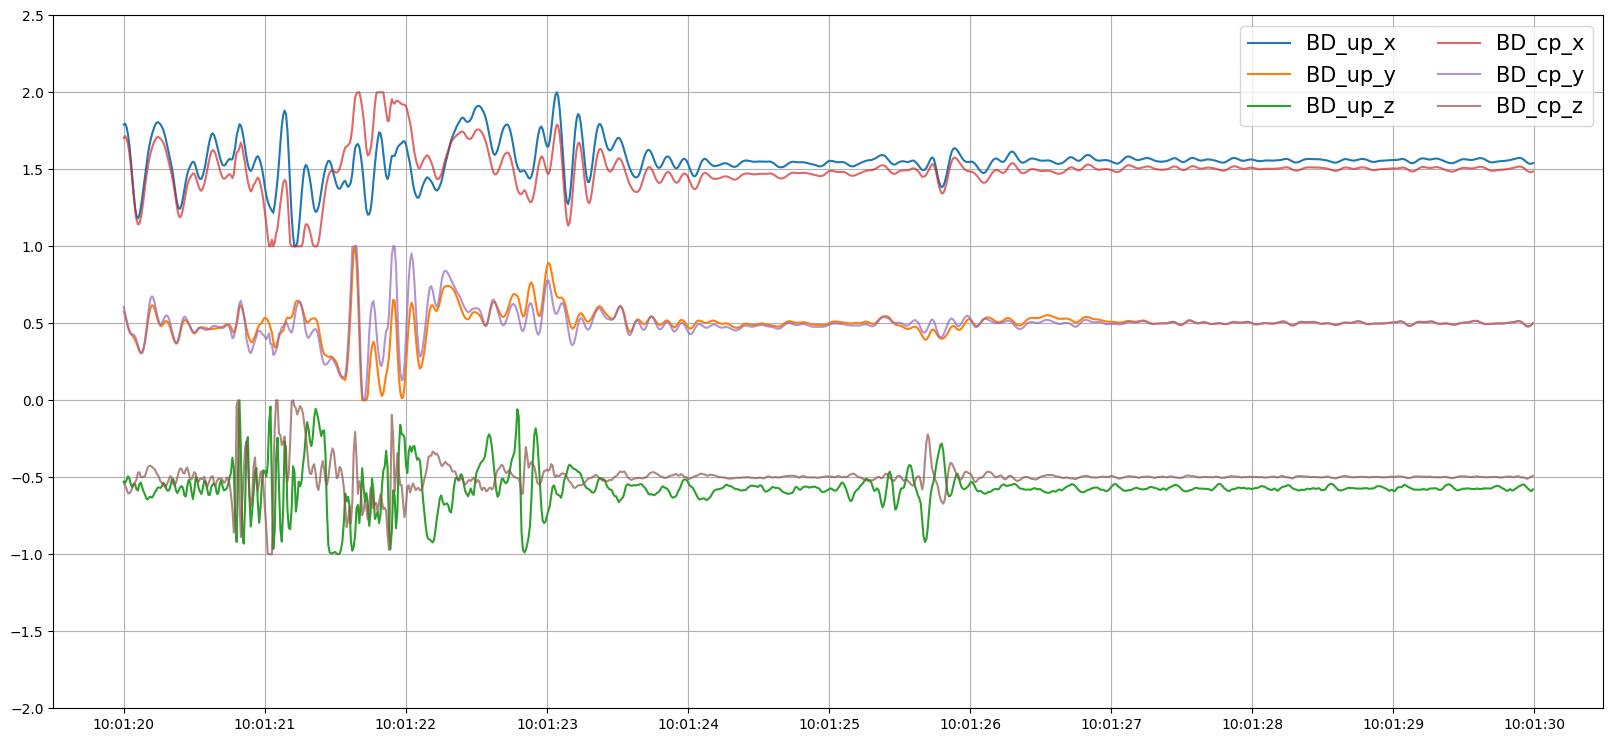

In [29]:
start_idx = start_bsg+2000
end_idx = start_idx + 1000
bd_select = 'BD_up'
bd_select = 'BD_compare'
print("Start index:", start_idx, "End index:", end_idx)
t = np.arange(len(data[bd_select][1])) / fs
t = pd.to_datetime(data['Timestamp']) + pd.Timedelta(hours=8)
plt.figure(figsize=(20, 9))
bd_select = 'BD_compare'
plt.plot(t[start_idx:end_idx], norm_sig(data[bd_select][0, start_idx:end_idx])+1, label='BD_up_x')
plt.plot(t[start_idx:end_idx], norm_sig(data[bd_select][1, start_idx:end_idx]), label='BD_up_y')
plt.plot(t[start_idx:end_idx], norm_sig(data[bd_select][2, start_idx:end_idx])-1, label='BD_up_z')

# single_sig = data['BD_side'][2, start_idx:end_idx]
# bd_select = 'BD_side'
bd_select = 'BD_up'
# env, sig_new = extract_hilbert_envelope_and_remove(single_sig, smooth_win= 205, remove_method="divide")
plt.plot(t[start_idx:end_idx], norm_sig(data[bd_select][0, start_idx:end_idx])+1, label='BD_cp_x', alpha=0.7)
plt.plot(t[start_idx:end_idx], norm_sig(data[bd_select][1, start_idx:end_idx]), label='BD_cp_y', alpha=0.7)
plt.plot(t[start_idx:end_idx], norm_sig(data[bd_select][2, start_idx:end_idx])-1, label='BD_cp_z', alpha=0.7)

plt.legend(ncol=2, fontsize=15)
plt.grid()
plt.ylim(-2, 2.5)
# plt.plot(t[start_idx:end_idx], norm_sig(scg_z[start_idx:end_idx]), label='SCG_z')

Start index: 28400 End index: 29400


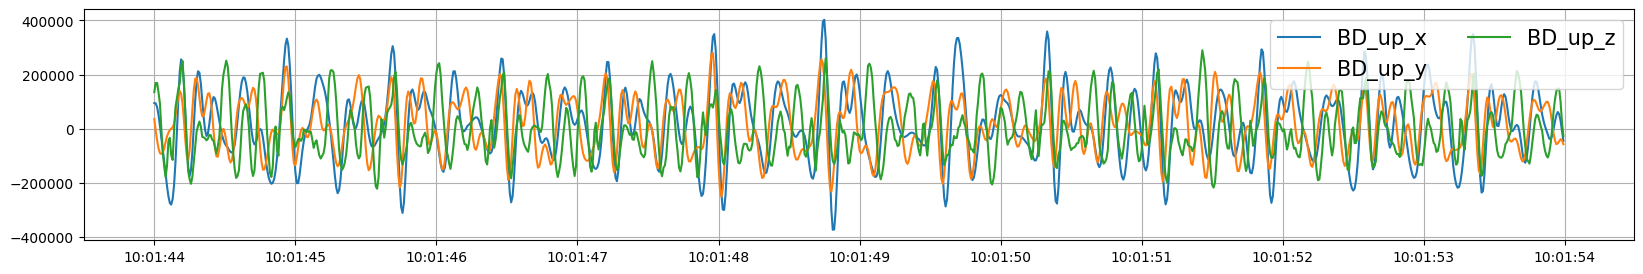

In [31]:
start_idx = start_bsg+2000
end_idx = start_idx + 1000
bd_select = 'BD_up'
bd_select = 'BD_compare'
print("Start index:", start_idx, "End index:", end_idx)
t = np.arange(len(data[bd_select][1])) / fs
t = pd.to_datetime(data['Timestamp']) + pd.Timedelta(hours=8)
plt.figure(figsize=(20, 3))
bd_select = 'BD_compare'
plt.plot(t[start_idx:end_idx], (data[bd_select][0, start_idx:end_idx]), label='BD_up_x')
plt.plot(t[start_idx:end_idx], (data[bd_select][1, start_idx:end_idx]), label='BD_up_y')
plt.plot(t[start_idx:end_idx], (data[bd_select][2, start_idx:end_idx]), label='BD_up_z')

# # single_sig = data['BD_side'][2, start_idx:end_idx]
# # bd_select = 'BD_side'
# bd_select = 'BD_up'
# # env, sig_new = extract_hilbert_envelope_and_remove(single_sig, smooth_win= 205, remove_method="divide")
# plt.plot(t[start_idx:end_idx], norm_sig(data[bd_select][0, start_idx:end_idx])+1, label='BD_cp_x', alpha=0.7)
# plt.plot(t[start_idx:end_idx], norm_sig(data[bd_select][1, start_idx:end_idx]), label='BD_cp_y', alpha=0.7)
# plt.plot(t[start_idx:end_idx], norm_sig(data[bd_select][2, start_idx:end_idx])-1, label='BD_cp_z', alpha=0.7)

plt.legend(ncol=2, fontsize=15)
plt.grid()
# plt.ylim(-2, 2.5)
# plt.plot(t[start_idx:end_idx], norm_sig(scg_z[start_idx:end_idx]), label='SCG_z')

In [ ]:
sdfsd

NameError: name 'sdfsd' is not defined

In [ ]:
save_path = '/Users/zyy/Desktop/Post_Doc/Code/Paper Plot'
np.save(os.path.join(save_path, 'bsg_attenu.npy'), data['BD_compare'][:, start_idx:end_idx])